In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'
%pylab inline

import jax
import jax.numpy as jnp
import tensorflow_probability as tfp; tfp = tfp.substrates.jax
tfd = tfp.distributions
tfb = tfp.bijectors

from jaxlie import SO3
from so3dm.distributions.isotropic_gaussian import IsotropicGaussianSO3
from so3dm.plotting import visualize_so3_probabilities

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## Create test distribution

In [2]:
@jax.jit
@jax.vmap
def sample_checkerboard(seed, size=np.pi):
    key1, key2, key3 = jax.random.split(seed, 3)
    x1 = jax.random.uniform(key=key1) * size - size/2
    x2_ = jax.random.uniform(key=key2) - jax.random.randint(minval=0, maxval=2,shape=[], key=key3) * 2
    x2 = x2_ + (jnp.floor(x1) % 2)
    data = jnp.stack([x1, x2]) * size/2
    Rs = SO3.from_rpy_radians(pitch=data[0]/2, yaw=data[1], roll=0).as_matrix()
    return Rs

In [3]:
# Create a checkerboard grid
Rs = sample_checkerboard(jax.random.split(jax.random.PRNGKey(0), 1024))

In [4]:
Rs.shape

(1024, 3, 3)

/local/home/flanusse/repo/SO3DiffusionModels/so3dm/plotting.py:100: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
/local/home/flanusse/repo/SO3DiffusionModels/so3dm/plotting.py:102: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'90$\degree$', None,


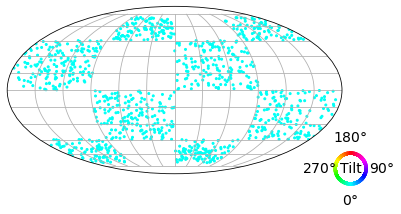

In [5]:
visualize_so3_probabilities(
    Rs,
    0.001);

## Create the noisy dataset

In [6]:
# This will decide our noise schedule, to start with, here I use a linear noise schedule in 
# variance, based on the Variance Exploding SDE (note, slightly diffrent from the choices of Ho et al.)
# This is not necessarily the best choice, this is just for testing
delta = 0.01 # delta in noise variance
noise_schedule = jnp.arange(0.01,0.9, delta) # Noise variance

In [7]:
@jax.jit
@jax.vmap
def sample(R, scale, seed):
    key1, key2 = jax.random.split(seed)
    x = SO3.from_matrix(R)
    
    # Sampling from current temperature
    dist = IsotropicGaussianSO3(x, scale)
    qn = dist.sample(seed=key1)
    
    # Sampling from next temperature step 
    dist2 = IsotropicGaussianSO3(qn, jnp.sqrt(delta))
    qnplus1 = dist2.sample(seed=key2)
    
    return {'x': x.wxyz, 'yn': qn, 'yn+1': qnplus1, 
            'sn':scale, 'sn+1':jnp.sqrt(scale**2 + delta)}

@jax.jit
def get_batch(seed, batch_size=512):
    key1, key2, key3 = jax.random.split(seed,3)
    # Sample from the target distribution
    Rs = sample_checkerboard(jax.random.split(key1, batch_size))
    
    # Sample random noise levels from the schedule
    s = jax.random.choice(key3, noise_schedule, shape=[batch_size])
    s = jnp.sqrt(s)
    
    # Sample random rotations
    return sample(Rs, s, jax.random.split(key2, batch_size))

In [8]:
batch = get_batch(jax.random.PRNGKey(0))

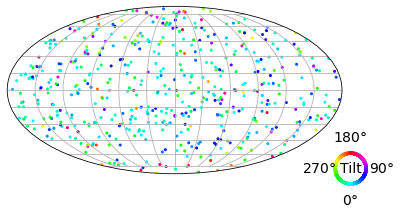

In [9]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(batch['yn']),
    0.001);

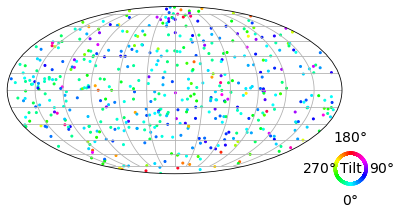

In [10]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(batch['yn+1']),
    0.001);

## Train a Denoising Diffusion Model without Analytical Solution

In [11]:
from so3dm.distributions.isotropic_gaussian import _isotropic_gaussian_so3_small
import haiku as hk
import optax

# Create a random sequence
rng_seq = hk.PRNGSequence(42)

In [12]:
def forward(x,s):
    net = jnp.concatenate([x,s],axis=-1)
    net = hk.nets.MLP([256, 256, 256], activation=jax.nn.leaky_relu)(net)
    # We use a residual connection, because we expect deviations to be small
    mu = hk.Linear(4)(net) + x
    # We force the normalization of the quaternion
    mu = mu / jnp.linalg.norm(mu,axis=-1, keepdims=True)
    scale = jax.nn.softplus(hk.Linear(1)(net)) + 0.001
    return mu, scale

model = hk.without_apply_rng(hk.transform(forward))
params = model.init(jax.random.PRNGKey(0), jnp.zeros([1,4]),jnp.zeros([1,1]))

losses = []
totsteps=0
from flax.metrics import tensorboard
summary_writer = tensorboard.SummaryWriter('test')

In [27]:
optimizer = optax.adam(learning_rate=1e-4)

In [28]:
opt_state = optimizer.init(params)

In [29]:
# The loss function is simply the probability log p(x_n|x_n+1)
def loss_fn(params, rng_key, batch):
    s = batch['sn+1'].reshape([-1,1])
    mu, scale = model.apply(params, batch['yn+1'], s)
    
    @jax.vmap
    def fn(x, mu, scale):
        dist = IsotropicGaussianSO3(mu, scale, 
                                    force_small_scale=True)
        return dist.log_prob(x)
    
    loss = - fn(batch['yn'], mu, scale)
    
    return jnp.mean(loss)

In [30]:
@jax.jit
def update(params, rng_key, opt_state, batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng_key, batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, new_opt_state

In [31]:
for step in range(100000):
    batch = get_batch(seed=next(rng_seq))
    loss, params, opt_state = update(params, next(rng_seq), opt_state, batch)
    totsteps+=1
    losses.append(loss)
    if isnan(loss):
        break
    if step % 5 ==0:
        summary_writer.scalar('train_loss', loss, totsteps)

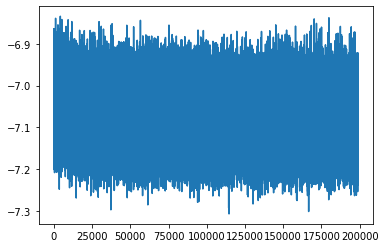

In [32]:
plot(losses[1000:])

## Sampling from the model

Note that here, this is only a small test, starting from a noised version of the target distribution, not uniform noise

In [33]:
# Try to sample with the trained model
nsamps = 100000
points = sample_checkerboard(jax.random.split(jax.random.PRNGKey(0), nsamps))
points = sample(points, jnp.sqrt(noise_schedule[-1])*jnp.ones(nsamps), jax.random.split(jax.random.PRNGKey(2), nsamps))

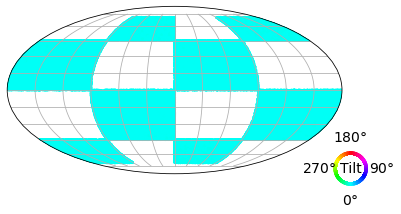

In [34]:
# Target distribution
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(points['x']),
    0.001);

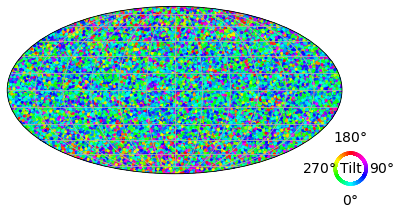

In [36]:
# Samples at T=~1
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(points['yn']),
    0.001);

In [37]:
# Running the denoising loop
x = points['yn']

@jax.jit
@jax.vmap
def fn_sample(mu,s,key):
    return IsotropicGaussianSO3(mu, s, force_small_scale=True).sample(seed=key)

for variance in noise_schedule[::-1]:
    mu, s = model.apply(params, x, jnp.sqrt(variance)*jnp.ones([nsamps,1]))
    x = fn_sample(mu, s, jax.random.split(next(rng_seq), nsamps))

In [39]:
from so3dm.plotting import visualize_so3_density

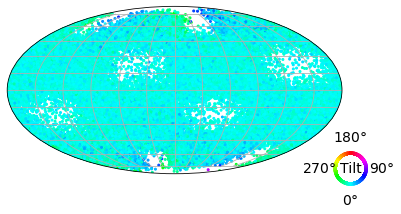

In [38]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(x),
    0.001);

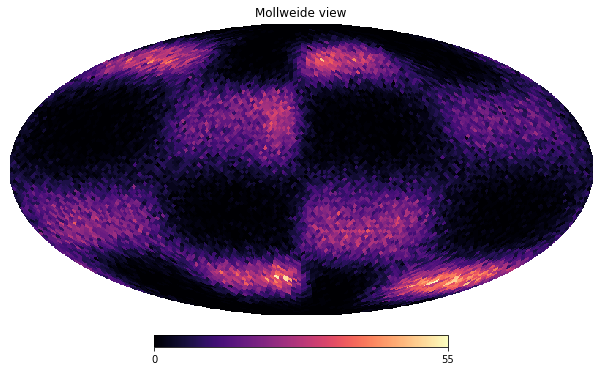

In [40]:
visualize_so3_density(
    jax.vmap(lambda x: SO3(x).as_matrix())(x), 32);